In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv(r"C:\Users\ilakk\Desktop\cognify tech\unified mentor\European_Bank.csv")



In [2]:
df.head()
df.info()
df.describe(include='all')
df['Exited'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [3]:
df.notnull()
df.isna().sum()

num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(exclude=np.number).columns.tolist()

for col in num_cols:
    df[col].fillna( value=df[col].median(),inplace=True)

for col in cat_cols:
    df[col].fillna(value=df[col].mode()[0],inplace =True)    

C:\Users\ilakk\AppData\Local\Temp\ipykernel_12788\478169287.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna( value=df[col].median(),inplace=True)
C:\Users\ilakk\AppData\Local\Temp\ipykernel_12788\478169287.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [4]:
drop_cols=['CustomerId','Surname']
df.drop(columns=drop_cols,inplace=True,errors='ignore')

In [5]:
cat_features=['Geography','Gender']
df=pd.get_dummies(df,columns=cat_features,drop_first=True)

In [6]:
# Feature Engineering
# 1.Balance-to-Salary ratio
df['Balance_to_Salary']=df['Balance']/(df['EstimatedSalary']+1e-6)

# 2.Product density indicator
df['Product_Density']=df['NumOfProducts']/(df['Tenure']+1)

# 3.Engagement-product interaction
df['Product_Engagement'] = df['IsActiveMember']*df['NumOfProducts']

# 4.Age-tenure interaction
df['Age_Tenure']=df['Age']*df['Tenure']






In [7]:
target='Exited'
y=df[target]

X=df.drop(columns=[target])
feature_names=X.columns.tolist()

In [8]:
#Stratifird Train_Test Split
from sklearn.model_selection import train_test_split


In [9]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X.select_dtypes(include=np.number).columns
scaler= StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [11]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

def eval_model(name, model, X_tr,y_tr,X_tes,y_tes):
    y_pred=model.predict(X_tes)
    y_proba=model.predict_proba(X_tes)[:, 1]

    accuracy=accuracy_score(y_tes,y_pred)
    precision=precision_score(y_tes,y_pred)
    recall=recall_score(y_tes,y_pred)
    f1=f1_score(y_tes,y_pred)
    auc=roc_auc_score(y_tes,y_proba)

    print(f"=== {name} ===")
    print(f"Accuracy:{accuracy:.3f}")
    print(f"Precision:{precision:.3f}")
    print(f"Recall:{recall:.3f}")
    print(f"f1_score:{f1:.3f}")
    print(f"roc-auc:{auc:.3f}\n")

    return {
        "model":name,
        "accuracy": accuracy,
        "precision":precision,
        "recall":recall,
        "f1": f1,
        "roc-auc":auc
    }

In [12]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

results = []
results.append(
    eval_model("Logistic Regression", log_reg,
                   X_train_scaled, y_train,
X_test_scaled, y_test))


=== Logistic Regression ===
Accuracy:0.710
Precision:0.383
Recall:0.698
f1_score:0.494
roc-auc:0.776



In [13]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=6,min_samples_leaf=50,class_weight='balanced',random_state=42)
dt.fit(X_train, y_train)

results.append(eval_model("Decision Tree", dt, X_train,y_train,X_test,y_test))

=== Decision Tree ===
Accuracy:0.757
Precision:0.444
Recall:0.774
f1_score:0.565
roc-auc:0.830



In [14]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators =300,
                            max_depth=None,min_samples_leaf=20,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)

results.append(eval_model("Random Forest", rf, X_train, y_train,X_test,y_test))


=== Random Forest ===
Accuracy:0.810
Precision:0.525
Recall:0.727
f1_score:0.610
roc-auc:0.864



In [15]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
results.append(eval_model("Gradient Boosting", gb,X_train,y_train,X_test,y_test))

=== Gradient Boosting ===
Accuracy:0.869
Precision:0.787
Recall:0.489
f1_score:0.603
roc-auc:0.868



In [16]:
from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,objective='binary:logistic',random_state=42,eval_metric='logloss')
xgb.fit(X_train,y_train)
results.append(eval_model("XGBoost",xgb,X_train,y_train,X_test,y_test))
                  

=== XGBoost ===
Accuracy:0.870
Precision:0.784
Recall:0.499
f1_score:0.610
roc-auc:0.863



In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print("Random Forest CV ROC-AUC:", cv_scores.mean(), "+/-", cv_scores.std())

Random Forest CV ROC-AUC: 0.8580048122200559 +/- 0.00825179975576615


In [18]:
import os
os.makedirs("models",exist_ok=True)

In [19]:
import joblib

best_model=rf
joblib.dump(best_model,"models/churn_model.pkl")
joblib.dump(scaler,"models/scaler.pkl")
joblib.dump(feature_names,"models/feature_names.pkl")


['models/feature_names.pkl']

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


df=pd.read_csv(r"C:\Users\ilakk\Desktop\cognify tech\unified mentor\European_Bank.csv")
y = df['Exited']    
X = df.drop(columns=['Exited', 'CustomerId', 'Surname']) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                    'NumOfProducts', 'EstimatedSalary',]   
categorical_features = ['Geography', 'Gender']  


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [21]:
import numpy as np
import pandas as pd
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

feature_names_num = numeric_features

# get the OneHotEncoder inside the ColumnTransformer
ohe = preprocessor.named_transformers_['cat'] 
feature_names_cat = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([feature_names_num, feature_names_cat])
importances = classifier.feature_importances_

fi_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

fi_df.head(10)



,feature,importance
1,Age,0.233289
5,EstimatedSalary,0.165375
0,CreditScore,0.160574
3,Balance,0.158434
4,NumOfProducts,0.136036
2,Tenure,0.085398
7,Geography_Germany,0.023868
6,Geography_France,0.010135
8,Geography_Spain,0.009525
9,Gender_Female,0.008745


In [22]:
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

X_train_trans = preprocessor.transform(X_train)


'''import shap
#explainer   = shap.TreeExplainer(tree_model)
#shap_values = explainer.shap_values(X_train_trans)
#if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values, X_train, feature_names=feature_names)
sample_idx = 0
shap.force_plot(explainer.expected_value, shap_values[sample_idx,:], X_train.iloc[sample_idx,:])
'''

'import shap\n#explainer   = shap.TreeExplainer(tree_model)\n#shap_values = explainer.shap_values(X_train_trans)\n#if isinstance(shap_values, list):\n    shap_values_pos = shap_values[1]\nelse:\n    shap_values_pos = shap_values\n\nshap.summary_plot(shap_values, X_train, feature_names=feature_names)\nsample_idx = 0\nshap.force_plot(explainer.expected_value, shap_values[sample_idx,:], X_train.iloc[sample_idx,:])\n'

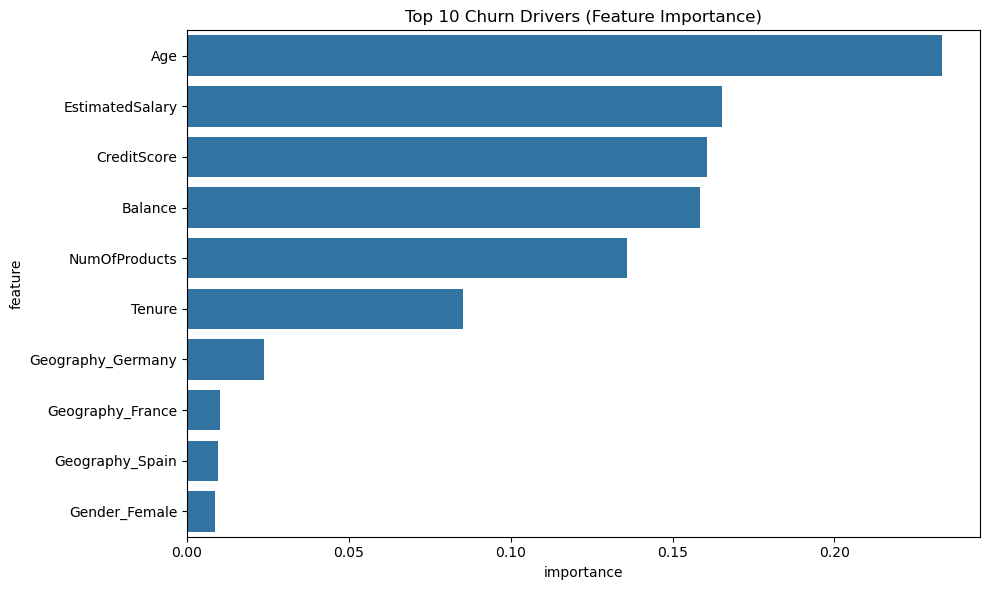

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(10), x='importance', y='feature')
plt.title('Top 10 Churn Drivers (Feature Importance)')
plt.tight_layout()
plt.savefig(r"C:\Users\ilakk\Desktop\cognify tech\unified mentor.png")
plt.show()


In [26]:
print("Available features:")
print(X_train.columns.tolist())

Available features:
['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [31]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

# Page config
st.set_page_config(
    page_title="Customer Churn Risk Dashboard",
    page_icon="📉",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Title and description
st.title("🏦 Customer Churn Risk Calculator")
st.markdown("""
**Predict customer churn probability** based on engagement and product utilization. 
Adjust inputs to see real-time risk changes and retention recommendations.
""")

# Load model and features
@st.cache_resource
def load_model():
    model = joblib.load("models/churn_model.pkl")
    feature_names = joblib.load("models/feature_names.pkl")
    return model, feature_names

model, feature_names = load_model()

# Sidebar for navigation
st.sidebar.header("Navigation")
page = st.sidebar.selectbox(
    "Choose a page:",
    ["Churn Risk Calculator", "What-if Simulator", "Feature Importance", "Probability Distribution"]
)

if page == "Churn Risk Calculator":
    st.header("1️⃣ Customer Churn Risk Calculator")
    
    with st.form("customer_form"):
        st.subheader("Customer Profile")
        col1, col2 = st.columns(2)
        with col1:
            credit_score = st.number_input("Credit Score", 300, 900, 650)
            age = st.number_input("Age", 18, 100, 35)
            tenure = st.slider("Tenure (years)", 0, 20, 5)
        with col2:
            balance = st.number_input("Balance", 0.0, 500000.0, 50000.0)
            num_products = st.slider("Number of Products", 1, 4, 2)
            est_salary = st.number_input("Estimated Salary", 0.0, 200000.0, 60000.0)
        
        st.subheader("Engagement & Products")
        col1, col2, col3 = st.columns(3)
        with col1:
            has_crcard = st.selectbox("Credit Card?", ["No", "Yes"])
        with col2:
            is_active = st.selectbox("Active Member?", ["No", "Yes"])
        with col3:
            satisfaction = st.slider("Satisfaction Score", 1, 5, 3)
        
        submitted = st.form_submit_button("🔮 Predict Churn Risk", use_container_width=True)
    
    if submitted:
        # Create input dataframe
        input_data = {
            'CreditScore': [credit_score],
            'Age': [age],
            'Tenure': [tenure],
            'Balance': [balance],
            'NumOfProducts': [num_products],
            'HasCrCard': [1 if has_crcard == "Yes" else 0],
            'IsActiveMember': [1 if is_active == "Yes" else 0],
            'EstimatedSalary': [est_salary],
            'Satisfaction Score': [satisfaction],
            'Points Earned': [1000.0]  # default
        }
        
        input_df = pd.DataFrame(input_data)
        
        # Predict
        churn_proba = model.predict_proba(input_df)[0, 1]
        churn_flag = "High Risk" if churn_proba > 0.5 else "Low Risk"
        
        # Display results
        col1, col2, col3 = st.columns([1, 2, 1])
        with col1:
            st.metric("Churn Probability", f"{churn_proba:.1%}")
        with col2:
            color = "🔴" if churn_proba > 0.5 else "🟢"
            st.metric(f"Risk Level", churn_flag, delta=f"{churn_proba:.1%}")
        
        st.success(f"**Recommendation:** {'Act now with retention offer' if churn_proba > 0.5 else 'Monitor engagement'}")

elif page == "What-if Simulator":
    st.header("2️⃣ What-if Scenario Simulator")
    st.markdown("**Compare baseline vs modified engagement to see churn impact**")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("📊 Baseline Customer")
        base_products = st.slider("Products (baseline)", 1, 4, 1, key="base_prod")
        base_active = st.selectbox("Active? (baseline)", ["No", "Yes"], key="base_act")
        base_satisfaction = st.slider("Satisfaction (baseline)", 1, 5, 2, key="base_sat")
    
    with col2:
        st.subheader("🎯 Optimized Scenario")
        opt_products = st.slider("Products (scenario)", 1, 4, 3, key="opt_prod")
        opt_active = st.selectbox("Active? (scenario)", ["No", "Yes"], key="opt_act")
        opt_satisfaction = st.slider("Satisfaction (scenario)", 1, 5, 4, key="opt_sat")
    
    if st.button("Compare Scenarios", type="primary"):
        # Baseline prediction
        base_data = {
            'CreditScore': [650], 'Age': [35], 'Tenure': [5],
            'Balance': [50000], 'NumOfProducts': [base_products],
            'HasCrCard': [1], 'IsActiveMember': [1 if base_active == "Yes" else 0],
            'EstimatedSalary': [60000], 'Satisfaction Score': [base_satisfaction],
            'Points Earned': [1000]
        }
        base_df = pd.DataFrame(base_data)
        base_proba = model.predict_proba(base_df)[0, 1]
        
        # Optimized prediction
        opt_data = base_data.copy()
        opt_data['NumOfProducts'] = [opt_products]
        opt_data['IsActiveMember'] = [1 if opt_active == "Yes" else 0]
        opt_data['Satisfaction Score'] = [opt_satisfaction]
        opt_df = pd.DataFrame(opt_data)
        opt_proba = model.predict_proba(opt_df)[0, 1]
        
        # Results
        col1, col2 = st.columns(2)
        with col1:
            st.metric("Baseline Risk", f"{base_proba:.1%}")
        with col2:
            st.metric("Optimized Risk", f"{opt_proba:.1%}", 
                     delta=f"{opt_proba - base_proba:+.1%}")
        
        if opt_proba < base_proba:
            st.balloons()
            st.success(f"✅ **Improvement:** {abs((opt_proba - base_proba)*100):.1f}% risk reduction!")

elif page == "Feature Importance":
    st.header("3️⃣ Feature Importance Dashboard")
    
    # Load or create feature importance (you'll save this from notebook)
    try:
        fi_df = joblib.load("models/feature_importance.pkl")
    except:
        # Fallback - compute on the fly
        preprocessor = model.named_steps['preprocessor']
        tree_model = model.named_steps['classifier']
        
        feature_names_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                           'NumOfProducts', 'EstimatedSalary']
        ohe = preprocessor.named_transformers_['cat']
        feature_names_cat = ohe.get_feature_names_out(['Geography', 'Gender'])
        
        all_features = np.concatenate([feature_names_num, feature_names_cat])
        importances = tree_model.feature_importances_
        
        fi_df = pd.DataFrame({
            'feature': all_features,
            'importance': importances
        }).sort_values('importance', ascending=False)
    
    st.subheader("Global Feature Importance")
    fig = px.bar(fi_df.head(10), x='importance', y='feature', 
                orientation='h', title="Top 10 Churn Drivers")
    st.plotly_chart(fig, use_container_width=True)
    
    st.subheader("Key Insights")
    col1, col2, col3 = st.columns(3)
    with col1:
        top_feature = fi_df.iloc[0]['feature']
        st.metric("Top Driver", top_feature)
    with col2:
        inactive_imp = fi_df[fi_df['feature'].str.contains('Active')]['importance'].iloc[0]
        st.metric("Activity Impact", f"{inactive_imp:.1%}")
    with col3:
        prod_imp = fi_df[fi_df['feature'].str.contains('Product')]['importance'].iloc[0]
        st.metric("Products Impact", f"{prod_imp:.1%}")

elif page == "Probability Distribution":
    st.header("4️⃣ Probability Distribution")
    
    # Sample predictions
    sample_size = st.slider("Sample size", 100, 2000, 500)
    sample_df = pd.DataFrame(np.random.randn(sample_size, X_train.shape[1]))
    sample_df.columns = feature_names
    
    sample_probs = model.predict_proba(sample_df)[:, 1]
    
    fig = px.histogram(x=sample_probs, nbins=20, 
                      title="Churn Probability Distribution (Sample)",
                      labels={'x': 'Churn Probability'})
    st.plotly_chart(fig, use_container_width=True)
    
    st.info(f"**{sum(sample_probs > 0.5)/len(sample_probs):.1%}** of sample predicted to churn")

# Footer
st.markdown("---")
st.markdown("""
**Customer Churn Analytics Dashboard**  
*Powered by Random Forest model focusing on engagement & product utilization*  
Developed for behavioral retention strategy insights
""")


2026-03-19 20:39:59.870 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 20:39:59.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 20:40:00.432 
  command:

    streamlit run c:\Users\ilakk\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-19 20:40:00.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 20:40:00.441 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 20:40:00.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 20:40:00.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator(_form_data=FormData(form_id='customer_form'))

In [ ]:

joblib.dump(rf, "models/churn_model.pkl")
joblib.dump(all_features, "models/feature_names.pkl")
joblib.dump(fi_df, "models/feature_importance.pkl")



['models/feature_importance.pkl']

C:\Users\ilakk\Desktop\cognify tech\unified mentor


SyntaxError: invalid syntax (663072818.py, line 1)